In [2]:
# BUILDING AND TRAING A LINEAR REGRESSION MODEL 

In [3]:
# IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score)

In [4]:
# Load data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

In [5]:
# Explore the data set

# Data set information
print("\nDataset information:")
print("\nFirst 5 rows:")
print(df.info())


Dataset information:

First 5 rows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paper

In [6]:
# Summary statistics
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [7]:
# Target Variable Distibution
print("\nTarget variable distribution:")
print(df["Churn"].value_counts())


Target variable distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


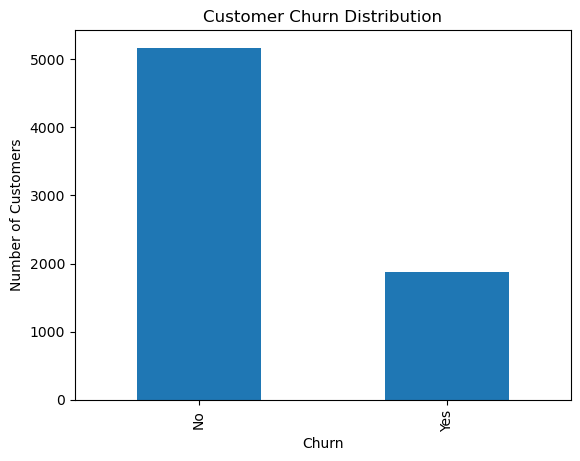

In [8]:
# Plotting the target variable
df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [9]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
# Convert Total Charges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove rows with missing Total Charges
df = df.dropna(subset=["TotalCharges"])

print("\nTarget variable after conversion:")
print(df["Churn"].unique())
print(df["Churn"].dtype)

# Converting the target variable into a binary
# Yes = 1 ( customer churned ), No = 0 ( customer stayed )
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Seperate feautures and target variables
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

# Converting categorical variables into dummy variables
# Reducing multicollinearity
X_encoded = pd.get_dummies(X, drop_first=True) # removes one category from each categorical variable
print("\nShape after encoding:")
print(X_encoded.shape)
print("\nFirst few encoded columns:")
print(X_encoded.head())


Target variable after conversion:
['No' 'Yes']
object

Shape after encoding:
(7032, 30)

First few encoded columns:
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                    

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes
print("X_train shape:", X_train.shape) 
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 30)
X_test shape: (1407, 30)
y_train shape: (5625,)
y_test shape: (1407,)


In [12]:
# Scaling the data : the shapes do not change because scaling changes the values of the feautures and not the number of rows or columns.

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the data
X_train_scaled = scaler.fit_transform(X_train) # learns the average and the spread of the data ( standard deviation ) for each feature from the training data and then scales the data. 

# Transform the test data using the same fitted scaler
X_test_scaled = scaler.transform(X_test) # we don't use the fit.transform because the model should not learn anything from the test data. the test data is only used to evaluate the model after training.

print("X_train_scaled shape:", X_train.shape)
print("X_test_scaled shape:", X_test.shape)

X_train_scaled shape: (5625, 30)
X_test_scaled shape: (1407, 30)


In [21]:
# Create the model with class_weight='balanced'
#    This automatically gives more weight to the minority class (churners)
model = LogisticRegression(
    max_iter=3000, # the initial model max was 1000 and it produced a convergence warning, indicating that the optimization algorithm needed more iterations to find the find the optimal solution. Increasing it to 3000 allowed the model to converge successfully.
    random_state=42,
    class_weight='balanced',) # incoporated the class weight balance because it will help us be able to catch almost every customer who will churn , it might incorrectly flag some customers who would have stayed however it is better to contact a few extra customers than to miss a customer who would have actually left. 

# Train the model on the training data
model.fit(X_train_scaled, y_train)

print("Logistic Regression Model trained successfully!")

Logistic Regression Model trained successfully!


In [14]:
# Making predictions 

# Predict customer churn ( 0 = No churn, 1 = churn )
y_pred = model.predict(X_test_scaled)

# Predict the probability of the churn
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Display the first 10 predictions
print("\nfirst 10 predicted classes:")
print(y_pred[:10])

# Display the first 10 predicted probabilities 
print("\nfirst 10 predicted probabilities:")
print(y_pred_proba[:10])


first 10 predicted classes:
[0 1 0 0 1 1 0 0 1 0]

first 10 predicted probabilities:
[0.15032718 0.98662724 0.00272362 0.0835099  0.93417341 0.9991059
 0.01507178 0.08269759 0.99710052 0.28938677]


/Users/mohau/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/mohau/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [15]:
# Understanding Prediction Probabilities
probability_examples = pd.DataFrame({
 "Actual Outcome": y_test.values[:10],
 "Predicted Probability": y_pred_proba[:10],
 "Predicted Class": y_pred[:10]
 })
print("\nProbability examples:")
print(probability_examples)


Probability examples:
   Actual Outcome  Predicted Probability  Predicted Class
0               0               0.150327                0
1               0               0.986627                1
2               0               0.002724                0
3               1               0.083510                0
4               0               0.934173                1
5               1               0.999106                1
6               0               0.015072                0
7               0               0.082698                0
8               1               0.997101                1
9               0               0.289387                0


In [16]:
# Model Evaluation

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Accuracy Score: 0.5849324804548686

Confusion Matrix:
 [[486 547]
 [ 37 337]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.47      0.62      1033
           1       0.38      0.90      0.54       374

    accuracy                           0.58      1407
   macro avg       0.66      0.69      0.58      1407
weighted avg       0.78      0.58      0.60      1407


ROC-AUC Score: 0.780353935114484


In [17]:
# The end ! 

In [20]:
# Interpration Logistic Regression Variables 
# We applied this in order to be able to identify the most important variables that had a significant influence on the customer churn.

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(coefficients)

                                  Feature  Coefficient
25                      Contract_Two year    -1.453725
10            InternetService_Fiber optic     1.269208
24                      Contract_One year    -0.787753
8          MultipleLines_No phone service     0.527617
21                        StreamingTV_Yes     0.438383
23                    StreamingMovies_Yes     0.424273
28         PaymentMethod_Electronic check     0.414435
9                       MultipleLines_Yes     0.365338
7                        PhoneService_Yes     0.337759
13                     OnlineSecurity_Yes    -0.322290
19                        TechSupport_Yes    -0.282003
26                   PaperlessBilling_Yes     0.256232
6                          Dependents_Yes    -0.226167
0                           SeniorCitizen     0.206595
16   DeviceProtection_No internet service    -0.190347
22    StreamingMovies_No internet service    -0.190347
20        StreamingTV_No internet service    -0.190347
18        